# Transparent Medical Image Classification via Explainable AI
## Phase 6 — Full Explainability Pipeline Demo

**Objective:** This notebook is a clean, end-to-end demonstration of the
full XAI pipeline. One chest X-ray goes in — the model predicts Normal or
Pneumonia with a probability score, and all three explanation methods
(Grad-CAM, SHAP, LIME) are applied and displayed together in a single
professional figure. This serves as the visual proof of concept for the
project.

**Author:** Eman Ayman Ahmed Abukhousa
**Program:** BSc Data Science & Artificial Intelligence, IITG — Year 3

## 01. Setup — Model, Libraries & Drive

All required libraries are imported and the trained ResNet-50 checkpoint
is loaded. The model is set to eval() mode and all inplace ReLU operations
are disabled to ensure compatibility with all three XAI methods.

In [35]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from PIL import Image
from google.colab import drive

drive.mount('/content/drive')

try:
    import cv2
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'opencv-python-headless'], check=True)
    import cv2

import subprocess
subprocess.run(['pip', 'install', 'shap', 'lime', '-q'], check=True)
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 1)
)

checkpoint_path = '/content/drive/MyDrive/medical-xai/best_model.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)
model.eval()

for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

print(f"Compute device : {device}")
print("Model loaded and ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Compute device : cuda
Model loaded and ready.


## 02. Preprocessing & Predict Functions

The same normalisation parameters from training are applied. Three predict
functions are defined — one for Grad-CAM, one for SHAP, and one for LIME —
ensuring each method receives correctly preprocessed input while working
with its required input format.

In [36]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5330, 0.5330, 0.5330],
                         std=[0.0349, 0.0349, 0.0349]),
])

def load_image(path):
    img_pil = Image.open(path).convert('RGB').resize((224, 224))
    tensor = val_transforms(img_pil).unsqueeze(0)
    return img_pil, tensor

# For SHAP
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return torch.sigmoid(self.model(x)).squeeze(-1)

wrapped_model = ModelWrapper(model).to(device)
wrapped_model.eval()

def predict_shap(imgs):
    imgs = torch.tensor(imgs, dtype=torch.float32).permute(0,3,1,2).to(device)
    mean = torch.tensor([0.5330, 0.5330, 0.5330]).view(1,3,1,1).to(device)
    std  = torch.tensor([0.0349, 0.0349, 0.0349]).view(1,3,1,1).to(device)
    imgs = (imgs - mean) / std
    with torch.no_grad():
        return wrapped_model(imgs).cpu().numpy()

# For LIME
def predict_fn(images):
    images = torch.tensor(images, dtype=torch.float32).permute(0,3,1,2).to(device)
    mean = torch.tensor([0.5330, 0.5330, 0.5330]).view(1,3,1,1).to(device)
    std  = torch.tensor([0.0349, 0.0349, 0.0349]).view(1,3,1,1).to(device)
    images = (images - mean) / std
    with torch.no_grad():
        output = torch.sigmoid(model(images))
    probs = output.squeeze(-1).cpu().numpy()
    return np.stack([1 - probs, probs], axis=1)

print("Transforms and predict functions ready.")

Transforms and predict functions ready.


## 03. Load Sample Images

One NORMAL and one PNEUMONIA image are loaded from the Kaggle test set.
These are the same images used across 07, 08, and 09 — ensuring
consistency across the full XAI pipeline demonstration.

In [37]:
from google.colab import userdata

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"emanaymanabukhousa","key":"{userdata.get("KAGGLE_KEY")}"}}\n')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia \
    -p /content/images --unzip

normal_img_path = '/content/images/chest_xray/test/NORMAL/IM-0028-0001.jpeg'
pneumo_img_path = '/content/images/chest_xray/test/PNEUMONIA/person80_bacteria_393.jpeg'

normal_pil, normal_tensor = load_image(normal_img_path)
pneumo_pil, pneumo_tensor = load_image(pneumo_img_path)

normal_np = np.array(normal_pil).astype(np.float32) / 255.0
pneumo_np = np.array(pneumo_pil).astype(np.float32) / 255.0

print(f" Normal    : {os.path.basename(normal_img_path)}")
print(f" Pneumonia : {os.path.basename(pneumo_img_path)}")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:24<00:00, 98.6MB/s]

 Normal    : IM-0028-0001.jpeg
 Pneumonia : person80_bacteria_393.jpeg


## 04. Grad-CAM Engine

Grad-CAM is initialised using hooks on layer4[2].conv3 — the final
convolutional layer of ResNet-50. This is identical to the implementation
in 07.

In [38]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor):
        input_tensor = input_tensor.to(device)
        input_tensor.requires_grad = True
        output = self.model(input_tensor)
        prob = torch.sigmoid(output)[0][0]
        self.model.zero_grad()
        prob.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, prob.item()

gradcam = GradCAM(model, model.layer4[2].conv3)

normal_cam, normal_prob   = gradcam.generate(normal_tensor.to(device))
pneumo_cam, pneumo_prob   = gradcam.generate(pneumo_tensor.to(device))

print(f"   Grad-CAM computed.")
print(f"   Normal    — p = {normal_prob:.3f}")
print(f"   Pneumonia — p = {pneumo_prob:.3f}")

   Grad-CAM computed.
   Normal    — p = 0.105
   Pneumonia — p = 1.000


## 05. SHAP Engine

SHAP PartitionExplainer is initialised with a blur masker baseline —
identical to 08. SHAP values are computed for both images.

In [39]:
masker = shap.maskers.Image("blur(128,128)", (224, 224, 3))
explainer_shap = shap.Explainer(predict_shap, masker)

normal_shap_vals = explainer_shap(normal_np[np.newaxis, ...],
                                   max_evals=500, batch_size=50)
pneumo_shap_vals = explainer_shap(pneumo_np[np.newaxis, ...],
                                   max_evals=500, batch_size=50)

normal_shap_map = normal_shap_vals.values[0].mean(axis=-1)
pneumo_shap_map = pneumo_shap_vals.values[0].mean(axis=-1)

print("SHAP computed.")

SHAP computed.


## 06. LIME Engine

LIME is initialised and applied to both images using 1000 samples and
10 superpixel features — identical to 09.

In [40]:
explainer_lime = lime_image.LimeImageExplainer(verbose=False)

def get_lime(img_np):
    explanation = explainer_lime.explain_instance(
        img_np.astype(np.double),
        predict_fn,
        top_labels=2,
        hide_color=0,
        num_samples=1000
    )
    temp, mask = explanation.get_image_and_mask(
        label=1,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )
    return temp, mask

print("Running LIME on normal image...")
normal_lime_temp, normal_lime_mask = get_lime(normal_np)
print("Running LIME on pneumonia image...")
pneumo_lime_temp, pneumo_lime_mask = get_lime(pneumo_np)

print("LIME computed.")

Running LIME on normal image...


  0%|          | 0/1000 [00:00<?, ?it/s]

Running LIME on pneumonia image...


  0%|          | 0/1000 [00:00<?, ?it/s]

LIME computed.


## 07. Full Pipeline Demo — One X-ray, Three Explanations

The complete explainability pipeline is visualised in a single professional
figure. Each row represents one image — the original X-ray, the model
prediction, and all three XAI explanations side by side. This is the
visual proof of concept for the project.

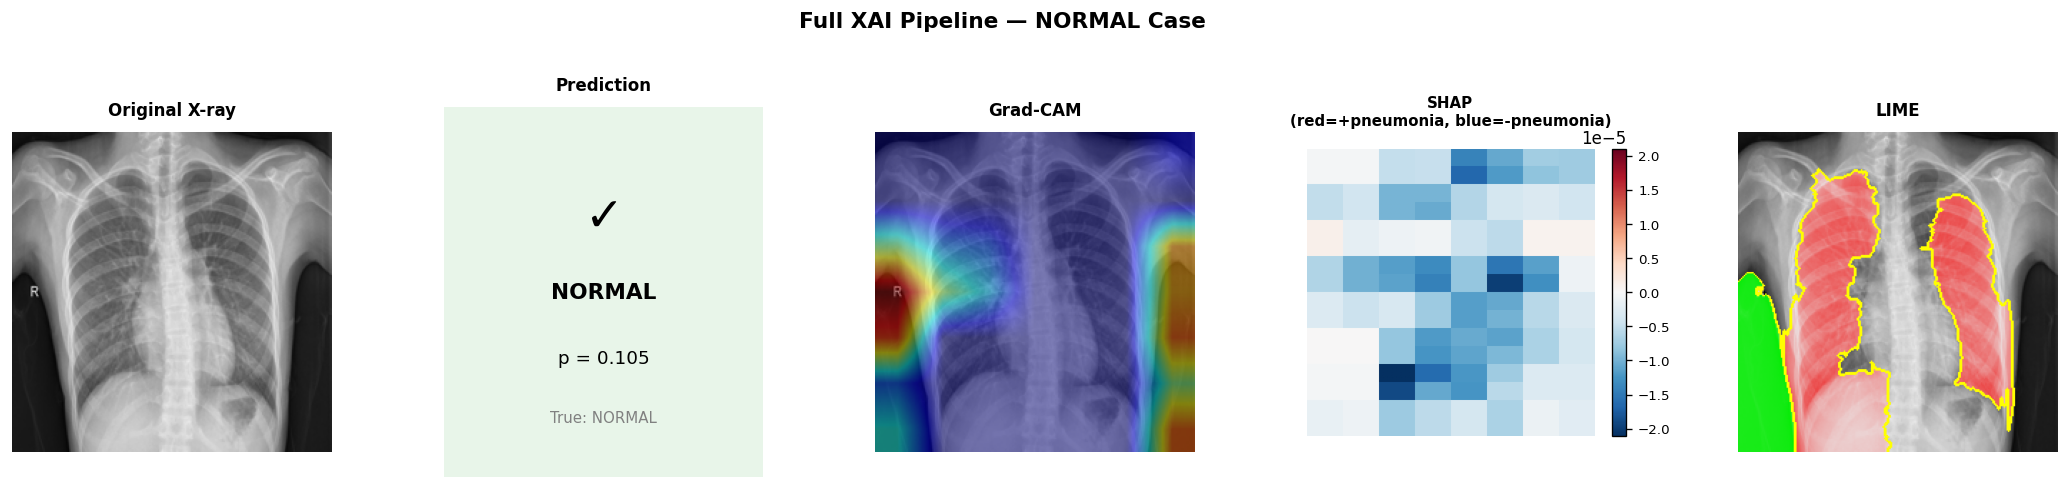

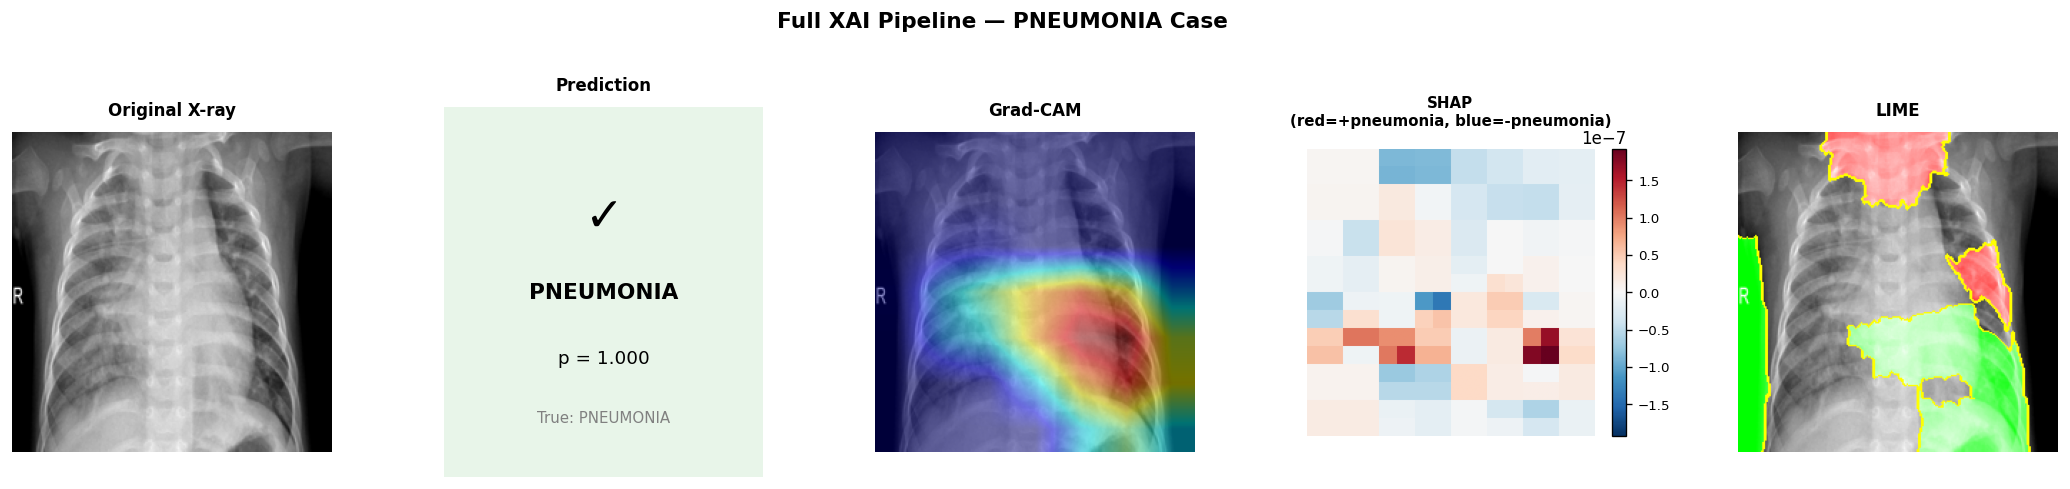

In [41]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from mpl_toolkits.axes_grid1 import make_axes_locatable

def overlay_cam(img_pil, cam):
    cam_uint8 = np.uint8(255 * cam)
    heatmap = cv2.applyColorMap(
        cv2.resize(cam_uint8, (224, 224)), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    img_np = np.array(img_pil)
    return np.uint8(0.45 * heatmap_rgb + 0.55 * img_np)

def run_demo(img_pil, cam, shap_map, lime_temp, lime_mask, true_label, prob):
    pred_label = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    correct = pred_label == true_label
    bg_colour = '#e8f5e9' if correct else '#fdecea'
    text_colour = 'black'
    symbol = '✓' if correct else '✗'

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.patch.set_facecolor('white')
    plt.subplots_adjust(wspace=0.35)

    # ORIGINAL
    axes[0].imshow(img_pil, cmap='gray')
    axes[0].set_title('Original X-ray', fontsize=10,
                      fontweight='bold', color=text_colour, pad=10)
    axes[0].axis('off')

    # PREDICTION
    axes[1].set_facecolor(bg_colour)
    axes[1].text(0.5, 0.70, symbol, ha='center', va='center',
                 fontsize=28, color=text_colour, transform=axes[1].transAxes)
    axes[1].text(0.5, 0.50, pred_label, ha='center', va='center',
                 fontsize=13, fontweight='bold', color=text_colour,
                 transform=axes[1].transAxes)
    axes[1].text(0.5, 0.32, f'p = {prob:.3f}', ha='center', va='center',
                 fontsize=11, color=text_colour,
                 transform=axes[1].transAxes)
    axes[1].text(0.5, 0.16, f'True: {true_label}', ha='center', va='center',
                 fontsize=9, color='gray',
                 transform=axes[1].transAxes)
    axes[1].set_title('Prediction', fontsize=10,
                      fontweight='bold', color=text_colour, pad=10)
    axes[1].set_xticks([]); axes[1].set_yticks([])
    for spine in axes[1].spines.values():
        spine.set_visible(False)

    # GRAD-CAM
    axes[2].imshow(overlay_cam(img_pil, cam))
    axes[2].set_title('Grad-CAM', fontsize=10,
                      fontweight='bold', color=text_colour, pad=10)
    axes[2].axis('off')

    # SHAP
    abs_max = np.abs(shap_map).max()
    shap_img = axes[3].imshow(shap_map, cmap='RdBu_r',
                               vmin=-abs_max, vmax=abs_max)
    axes[3].set_title('SHAP\n(red=+pneumonia, blue=-pneumonia)',
                      fontsize=9, fontweight='bold',
                      color=text_colour, pad=14)
    axes[3].axis('off')
    divider = make_axes_locatable(axes[3])
    cax = divider.append_axes("right", size="5%", pad=0.15)
    cbar = plt.colorbar(shap_img, cax=cax)
    cbar.ax.tick_params(labelsize=8, colors='black')

    # LIME — original clean version
    axes[4].imshow(mark_boundaries(lime_temp, lime_mask))
    axes[4].set_title('LIME', fontsize=10,
                      fontweight='bold', color=text_colour, pad=10)
    axes[4].axis('off')

    fig.suptitle(
        f'Full XAI Pipeline — {true_label} Case',
        fontsize=13, fontweight='bold', color='black', y=1.08
    )

    plt.savefig(
        f'/content/drive/MyDrive/medical-xai/demo_{true_label.lower()}.png',
        dpi=150, bbox_inches='tight', facecolor='white'
    )
    plt.show()

run_demo(normal_pil, normal_cam, normal_shap_map,
         normal_lime_temp, normal_lime_mask, 'NORMAL', normal_prob)

run_demo(pneumo_pil, pneumo_cam, pneumo_shap_map,
         pneumo_lime_temp, pneumo_lime_mask, 'PNEUMONIA', pneumo_prob)

## 08. XAI Comparison Analysis & Clinical Interpretation

### What the Colors Mean
- **Grad-CAM** — red = high activation (model attended here), blue = low activation
- **SHAP** — red = pushed prediction toward pneumonia, blue = pushed toward normal
- **LIME** — green segments = positively contributed to pneumonia prediction,
  red segments = negatively contributed, yellow boundary = segment border

### Agreement Across Methods — NORMAL Case
All three methods are consistent on the normal image (p = 0.105):
- Grad-CAM shows diffuse low activation with no dominant focus region
- SHAP assigns predominantly negative values across the image — pushing the
  prediction away from pneumonia
- LIME highlights peripheral regions outside the lung fields as suppressive

When all three methods agree, confidence in the explanation is higher.
This case suggests the model is correctly ignoring non-pathological features.

### Agreement Across Methods — PNEUMONIA Case
For the pneumonia image (p = 1.000):
- Grad-CAM focuses on the lower lung fields — consistent with bacterial
  pneumonia consolidation patterns
- SHAP shows positive contributions in the central and lower lung regions —
  clinically consistent with where opacity appears
- LIME identifies coarse superpixel regions in the right lung field rather
than precise anatomical boundaries — a known limitation of segment-based
explanation methods.

All three methods point toward the lung fields — suggesting the model is
attending to clinically relevant anatomy in this case. However, the exact
spatial focus differs slightly between methods, indicating that agreement
is partial rather than perfect.

### Disagreement & Limitations
Despite agreement on the pneumonia case, important differences exist:
- Grad-CAM provides coarse spatial localisation but loses resolution at 7×7
  feature map scale
- SHAP provides pixel-level contribution scores but can be noisy and harder
  to interpret visually
- LIME's output depends heavily on superpixel segmentation quality —
  different runs can produce different segment boundaries

### Trust Evaluation
A key principle of this pipeline:
- When all three methods agree → higher confidence in the explanation
- When methods disagree → the model's decision becomes questionable and
  should not be trusted for clinical use without further review

This demo represents a single-case illustration, not a statistically
generalizable result. Clinical deployment would require validation across
hundreds of cases with radiologist review.

### Can We Trust This Model?
For the pneumonia case: all three methods focus on lung fields →
the model appears to be focusing on clinically relevant regions → suggesting more reliable reasoning. However, agreement between XAI methods does not guarantee correctness, only
consistency of explanation. It remains possible that the model is learning
dataset-specific artifacts — such as intensity patterns or acquisition
differences — rather than purely pathological features.

For borderline or misclassified cases (as shown in 07–09 false negatives):
methods disagreed and focused on non-anatomical regions →
the model was reasoning incorrectly → **trust should be withheld**.

**Model confidence alone is not sufficient for diagnosis.
Explanation consistency across multiple XAI methods is required before
clinical trust can be established. This demonstrates that explainability is not a single-method problem, but a multi-perspective validation process. Future work should evaluate
explanation agreement quantitatively across a larger dataset.**

### Decision Threshold
A probability of ≥ 0.5 is used to classify as PNEUMONIA. This threshold
was selected based on the threshold analysis in 06. Changing this
threshold directly affects sensitivity and specificity — a clinical
deployment would require threshold tuning with a radiologist.

In [33]:
import shutil
shutil.copy(
    '/content/drive/MyDrive/Colab Notebooks/10_demo.ipynb',
    '/content/drive/MyDrive/medical-xai/10_demo.ipynb'
)
print("Notebook saved to Drive.")

Notebook saved to Drive.


In [34]:
import json

notebook_path = '/content/drive/MyDrive/medical-xai/10_demo.ipynb'

with open(notebook_path, 'r') as f:
    nb = json.load(f)

if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open(notebook_path, 'w') as f:
    json.dump(nb, f)

print("Notebook metadata cleaned.")

Notebook metadata cleaned.
